# 6주차_데이터 전처리와 파생변수 생성 Ⅰ


- 변수 구간화(Binning)


---

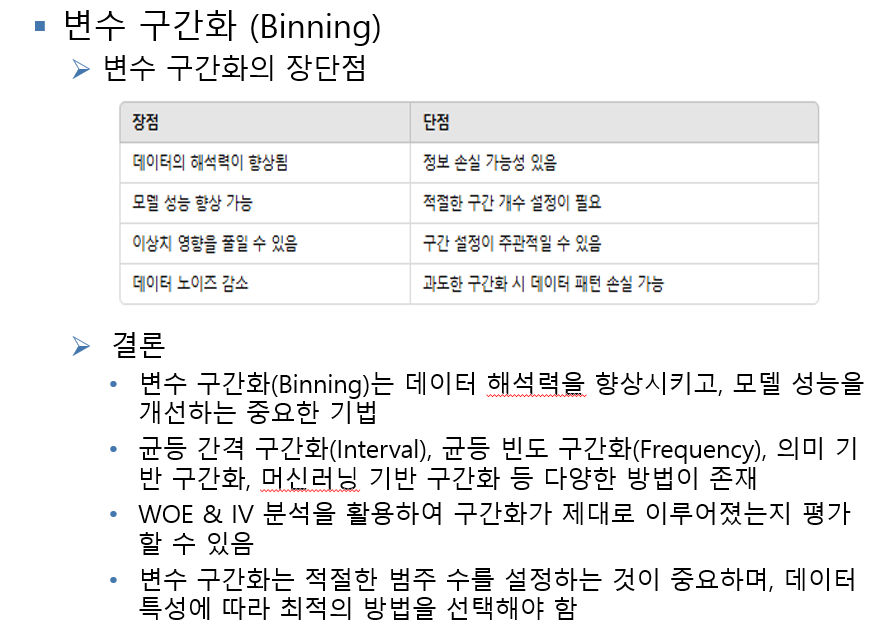

In [9]:
# 필요한 패키지 설치
# !pip install xverse  
# Weight of Evidence(WOE) 및 IV(Information Value) 계산을 지원하는 xverse 패키지 설치 명령어  
# Jupyter 환경에서는 실행 전 주석 해제 필요  
# 이미 설치되어 있다면 생략 가능함

from xverse.transformer import WOE  
# xverse 패키지 내에서 WOE 변환 기능을 담당하는 WOE 클래스 불러오기  
# 이 클래스는 범주형 또는 수치형 변수에 대해 WOE 기반의 수치 변환을 수행함  
# 로지스틱 회귀, 신용평가 모델 등의 입력 전처리에 적합함

import matplotlib.pyplot as plt  
# matplotlib 패키지의 시각화 도구인 pyplot 모듈 불러오기  
# plot(), scatter(), hist() 등 그래프 함수 사용 가능함

import pandas as pd  
# 데이터프레임 생성, 결합, 필터링 등을 위한 pandas 라이브러리 불러오기  
# 주요 데이터 처리 기반 도구로 활용함

import seaborn as sns  
# 고급 스타일 및 통계 시각화를 지원하는 seaborn 패키지 불러오기  
# matplotlib 기반의 확장 패키지로서 barplot, heatmap, countplot 등 고급 그래프 구현 가능함

plt.rcParams['figure.dpi'] = 300  
# 출력되는 모든 시각화의 해상도를 300 DPI로 설정함  
# 선명한 그래프 출력을 위해 사용되는 전역 설정임


In [10]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
df = pd.read_csv("../../main/datasets/heart_2020_cleaned.csv")

# 데이터 샘플 확인
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [11]:
# BMI 컬럼의 분포 확인

df['BMI'].describe()

count    319795.000000
mean         28.325399
std           6.356100
min          12.020000
25%          24.030000
50%          27.340000
75%          31.420000
max          94.850000
Name: BMI, dtype: float64

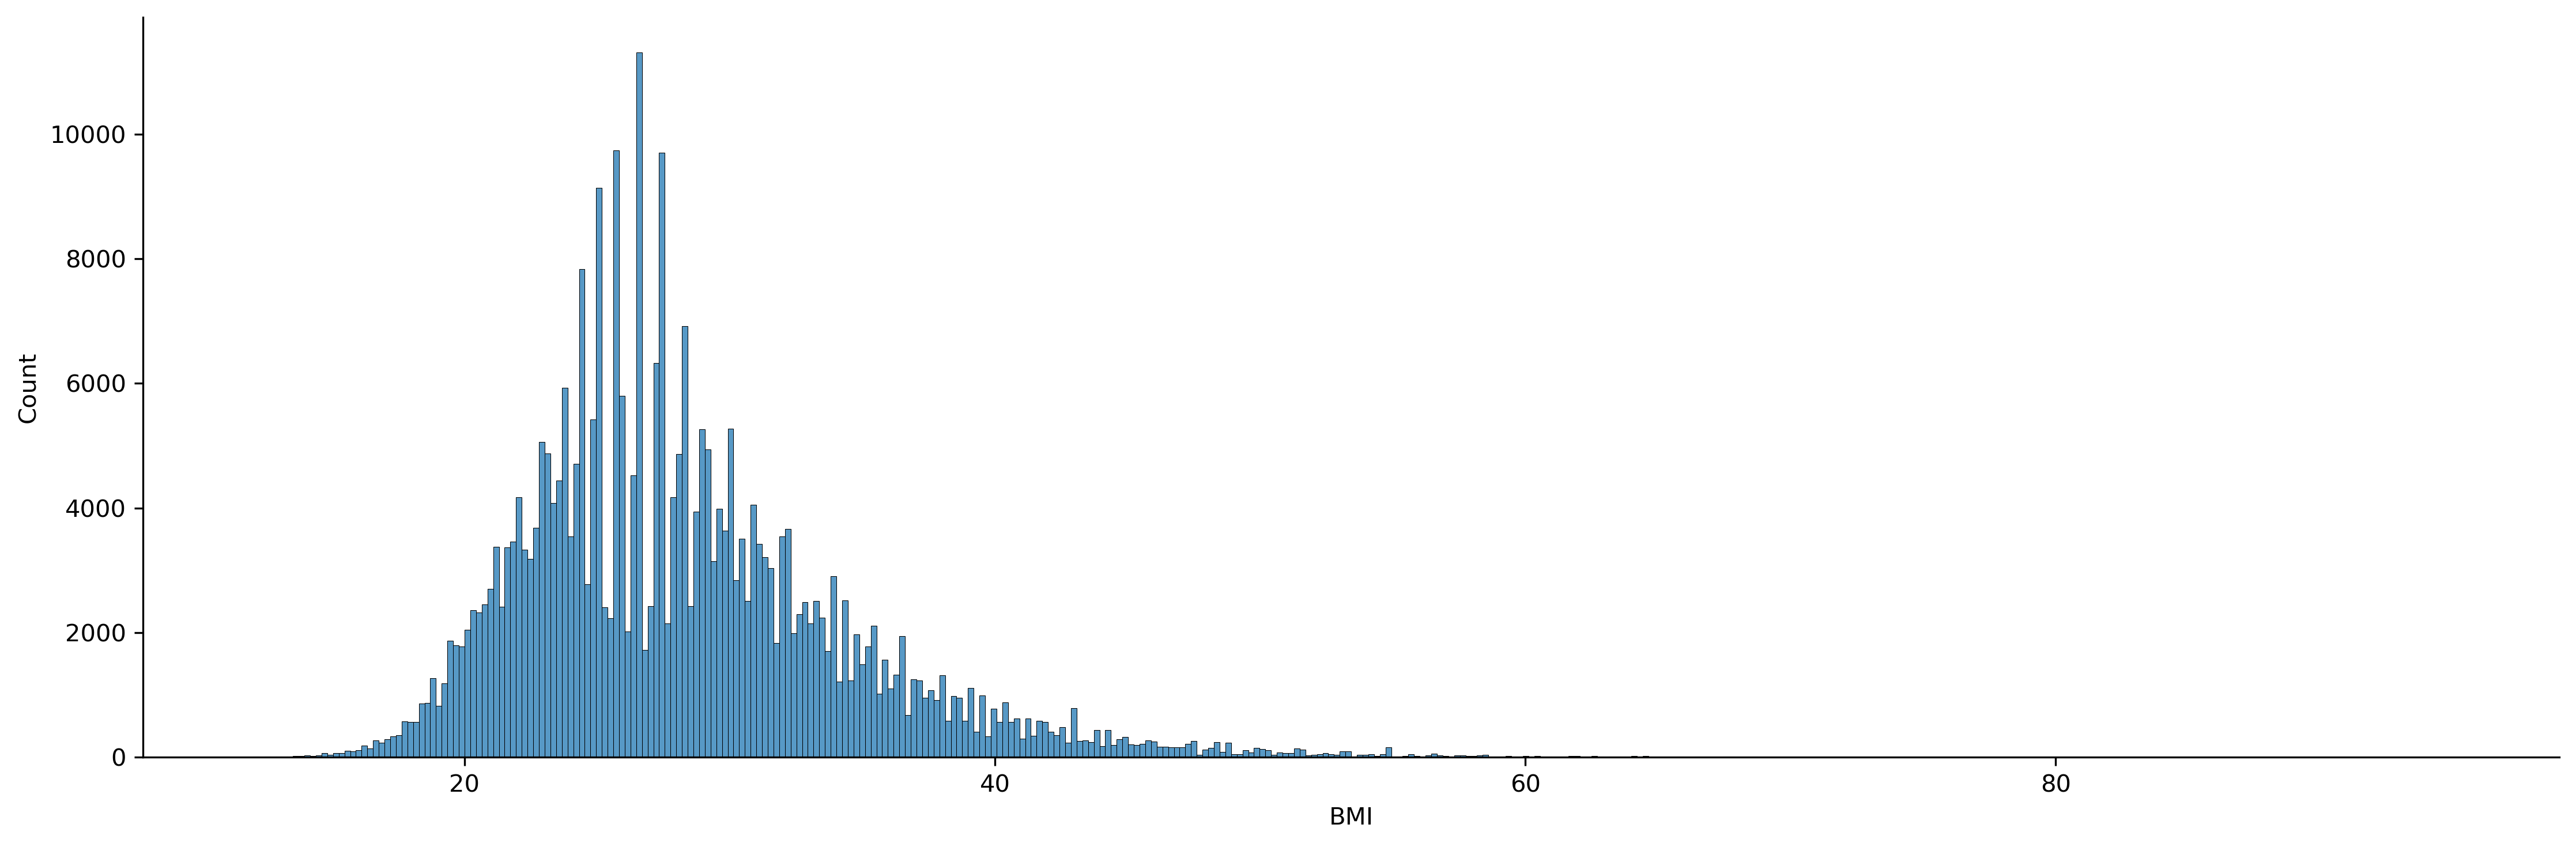

In [12]:
# BMdisplot() 함수를 이용해, 데이터프레임 df 안에 있는 'BMI' 컬럼의 분포를 시각화

%matplotlib inline
# Jupyter Notebook에서 시각화 결과가 셀 내부에 바로 출력되도록 설정하는 매직 명령어임
# Notebook 환경에서만 사용 가능하며, .py 스크립트에서는 생략하거나 오류가 발생함

# sns.displot()은 기본적으로 **히스토그램(histogram)**을 생성하는 함수

sns.displot(df['BMI'], height=5, aspect=3)
# seaborn의 displot() 함수를 사용하여 'BMI' 변수의 분포를 시각화함
# 히스토그램 형태로 데이터의 빈도 분포를 나타내며, KDE 곡선이 함께 그려질 수 있음 (기본값에서 자동 포함)
# height=5는 플롯의 높이를 5인치로 설정함
# aspect=3은 가로:세로 비율을 3으로 설정하여 가로 폭을 15인치로 조정함 (height × aspect = 5 × 3)
# 시각화의 폭을 넓게 조정함으로써 데이터 분포의 세부 구조를 더 잘 파악할 수 있도록 함

In [13]:
# 임의로 단순 구간화

df1 = df.copy()
# 원본 데이터프레임 df를 df1이라는 이름으로 복사함
# 이후 작업에서 원본을 손상시키지 않고 BMI 구간화를 적용하기 위함

# 구간화용 빈 컬럼 생성 - 생략해도 되지만 바로 옆에 붙여 보기 위함
df1.insert(2, 'BMI_bin', 0)
# df1 데이터프레임의 세 번째 열 위치(index=2)에 'BMI_bin'이라는 새 컬럼을 삽입함
# 초기값으로 모든 행에 대해 0을 넣어 설정함
# 시각적으로 BMI 옆에 구간화 컬럼이 붙도록 하여 확인을 용이하게 하기 위한 조치임

df1.loc[df1['BMI'] <= 20, 'BMI_bin'] = 'a'
# BMI가 20 이하인 행을 'a' 구간으로 분류함
df1.loc[(df1['BMI'] > 20) & (df1['BMI'] <= 30), 'BMI_bin'] = 'b'
# BMI가 20 초과 30 이하인 행을 'b' 구간으로 분류함
df1.loc[(df1['BMI'] > 30) & (df1['BMI'] <= 40), 'BMI_bin'] = 'c'
# BMI가 30 초과 40 이하인 행을 'c' 구간으로 분류함
df1.loc[(df1['BMI'] > 40) & (df1['BMI'] <= 50), 'BMI_bin'] = 'd'
# BMI가 40 초과 50 이하인 행을 'd' 구간으로 분류함
df1.loc[(df1['BMI'] > 50) & (df1['BMI'] <= 60), 'BMI_bin'] = 'e'
# BMI가 50 초과 60 이하인 행을 'e' 구간으로 분류함
df1.loc[(df1['BMI'] > 60) & (df1['BMI'] <= 70), 'BMI_bin'] = 'f'
# BMI가 60 초과 70 이하인 행을 'f' 구간으로 분류함
df1.loc[df1['BMI'] > 70, 'BMI_bin'] = 'g'
# BMI가 70을 초과하는 행을 'g' 구간으로 분류함

df1.head()
# 구간화된 결과를 포함한 df1 데이터프레임의 상위 5개 행을 출력함
# 'BMI_bin' 컬럼이 올바르게 구간화되었는지 시각적으로 확인하는 단계임


,HeartDisease,BMI,BMI_bin,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,a,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,b,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,b,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,b,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,b,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


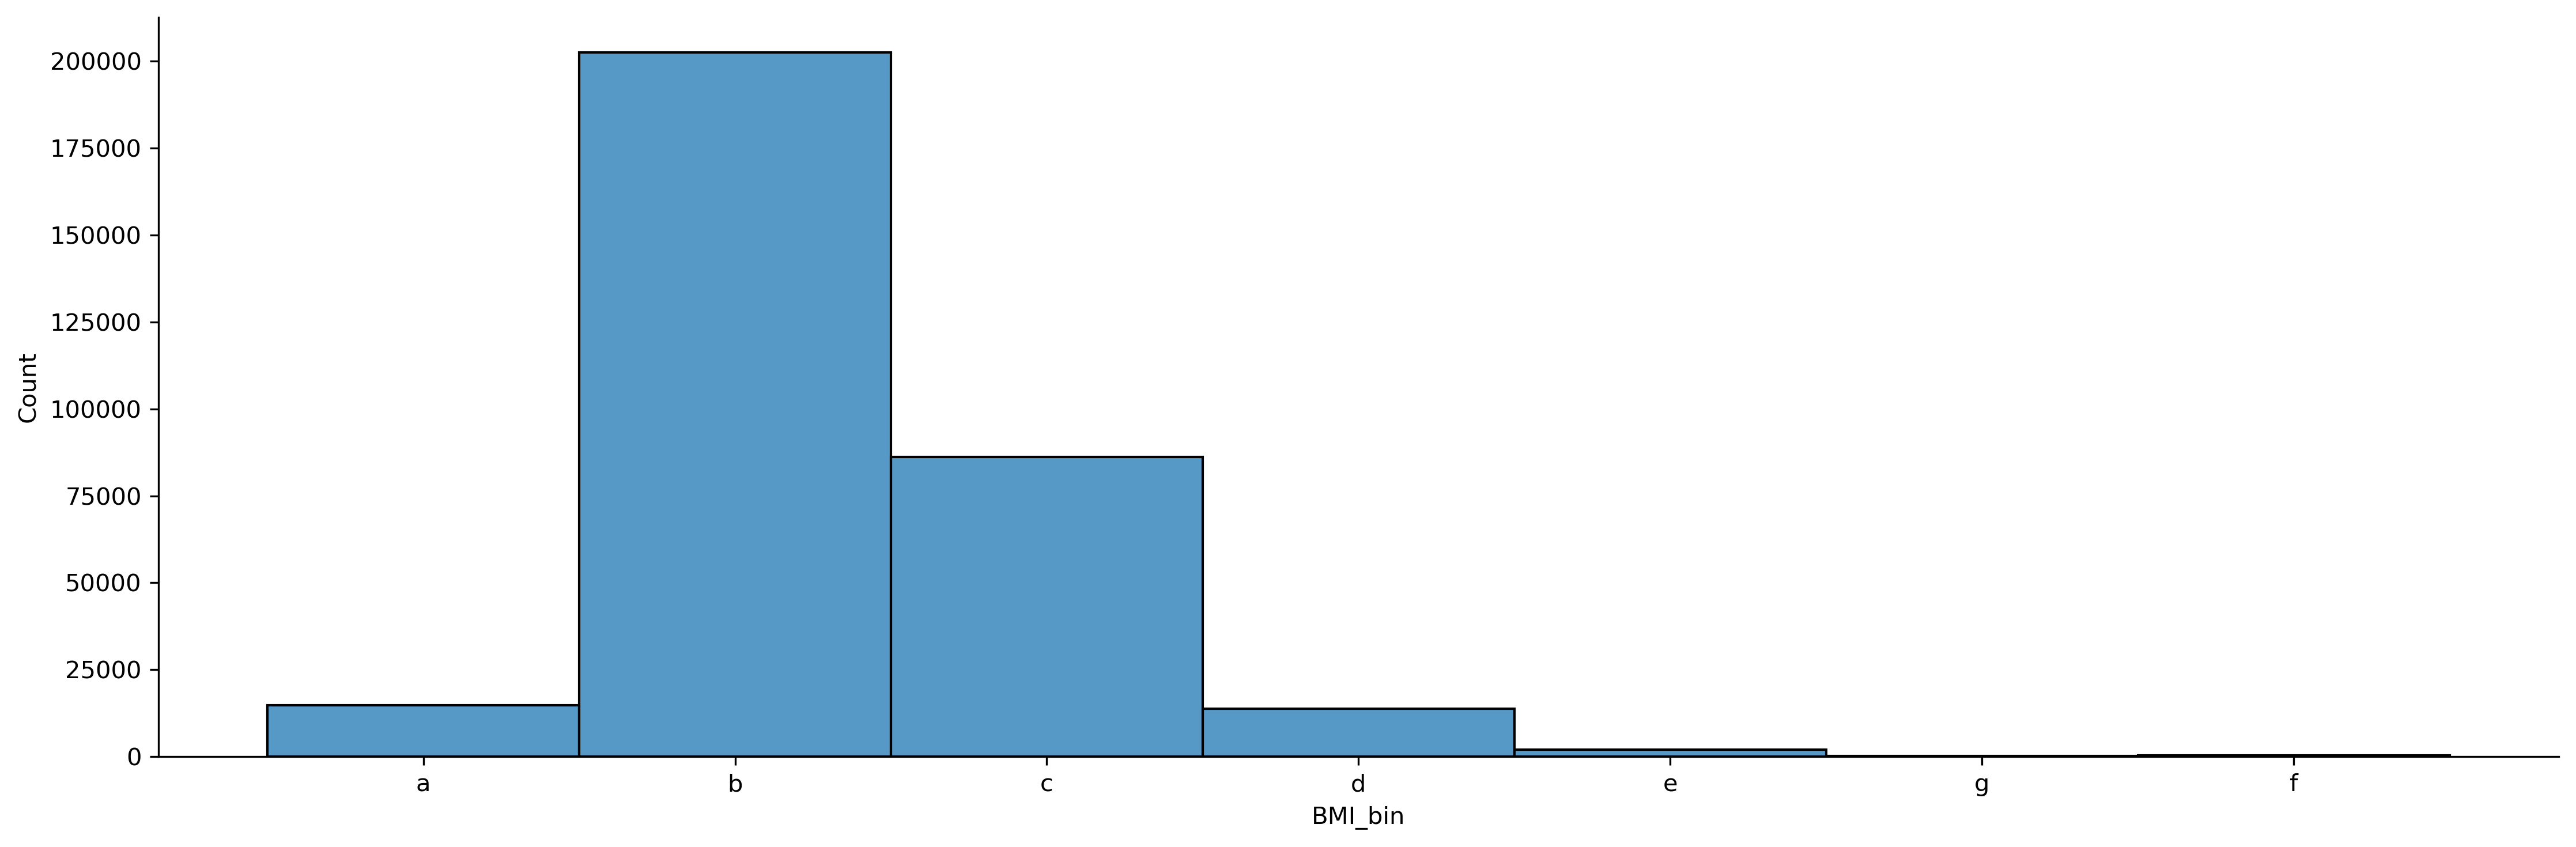

In [14]:
# 구간화 변수 분포 시각화

sns.displot(df1['BMI_bin'],height = 5, aspect = 3)

In [15]:
#  cut() 함수 사용하여 임의로 구간화
df1.insert(3, 'BMI_bin2', 0) # 구간화용 빈 컬럼 생성 

# pd.cut()은 연속형 데이터를 일정 구간으로 나눌 때 사용
# bins는 각 구간의 경계를 의미하며, [) 형태로 왼쪽 포함, 오른쪽 미포함
# labels는 각 구간에 대응되는 범주형 값
# 예를 들어 BMI가 25이면, [20~30) 구간이므로 'b' 라벨이 할당

df1['BMI_bin2'] = pd.cut(df1.BMI, bins=[0, 20, 30, 40, 50, 60, 70, 95]
                         , labels=['a', 'b', 'c', 'd', 'e', 'f', 'g'])

# df1의 'BMI' 값을 기준으로 특정 구간(bins)으로 나누어 범주형 변수로 변환
# 구간은 [0~20), [20~30), ..., [70~95) 총 7개로 나뉘며, 각 구간에 'a'부터 'g'까지의 라벨을 부여
# 결과는 새로운 열 'BMI_bin2'에 저장

df1.head()

,HeartDisease,BMI,BMI_bin,BMI_bin2,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,a,a,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,b,b,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,b,b,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,b,b,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,b,b,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [51]:
# BMI_bin2 구간 별 관측치 수 집계

df1.BMI_bin2.value_counts().to_frame().style.background_gradient(cmap='winter')

# # 'BMI_bin2' 컬럼의 각 범주별 개수를 계산
# # value_counts()는 각 라벨(a~g)의 빈도를 반환
# df1.BMI_bin2.value_counts()

# # 위 결과를 DataFrame 형태로 변환 (기존에는 Series였음)
# # 열 이름이 없던 데이터를 하나의 열로 구성된 DataFrame으로 바꿈
# .to_frame()

# # 스타일을 적용하여 시각적으로 보기 좋게 만듬
# # background_gradient는 값이 큰 칸일수록 색이 진하게 표시되도록 함
# # cmap='winter'는 파란색 계열의 색상 맵을 사용
# .style.background_gradient(cmap='winter')

,count
BMI_bin2,
b,202548
c,86198
a,14699
d,13839
e,2019
f,363
g,129


In [52]:
# qcut() 함수 사용하여 자동 구간화

# BMI를 자동으로 7개 구간으로 나누기 위한 컬럼 생성
df1.insert(4, 'BMI_bin3', 0)  # 5번째 열에 'BMI_bin3' 컬럼 삽입, 초기값 0 설정

# qcut()을 사용한 분위수 기반 구간화 수행
# BMI 값을 7개의 분위수로 분할하여 'a'부터 'g'까지 라벨 부여
# 라벨은 각 구간을 구분하기 위한 범주형 값으로 사용
df1['BMI_bin3'] = pd.qcut(df1.BMI, q=7, labels=['a', 'b', 'c', 'd', 'e', 'f', 'g'])
# qcut() 함수에서 사용하는 q는 quantile (분위수)의 약자
# 예를 들어 q=4이면, 전체 데이터를 4등분해서 각 구간에 데이터 수가 같도록 나눔
# 즉, 데이터의 값 크기 기준이 아니라, 개수 기준으로 나누는 방식
# q=7이면, 전체 데이터를 7등분하여 각 구간에 동일한 개수의 데이터가 들어가도록 구간을 설정

df1.head()

,HeartDisease,BMI,BMI_bin,BMI_bin2,BMI_bin3,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,...,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,a,a,a,Yes,No,No,3.0,30.0,...,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,b,b,a,No,No,Yes,0.0,0.0,...,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,b,b,d,Yes,No,No,20.0,30.0,...,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,b,b,b,No,No,No,0.0,0.0,...,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,b,b,b,No,No,No,28.0,0.0,...,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [53]:
# BMI_bin3 구간 별 관측치 수 집계

df1.BMI_bin3.value_counts().to_frame().style.background_gradient(cmap='winter')

,count
BMI_bin3,
b,47309
a,45980
d,45944
f,45805
g,45255
e,44977
c,44525


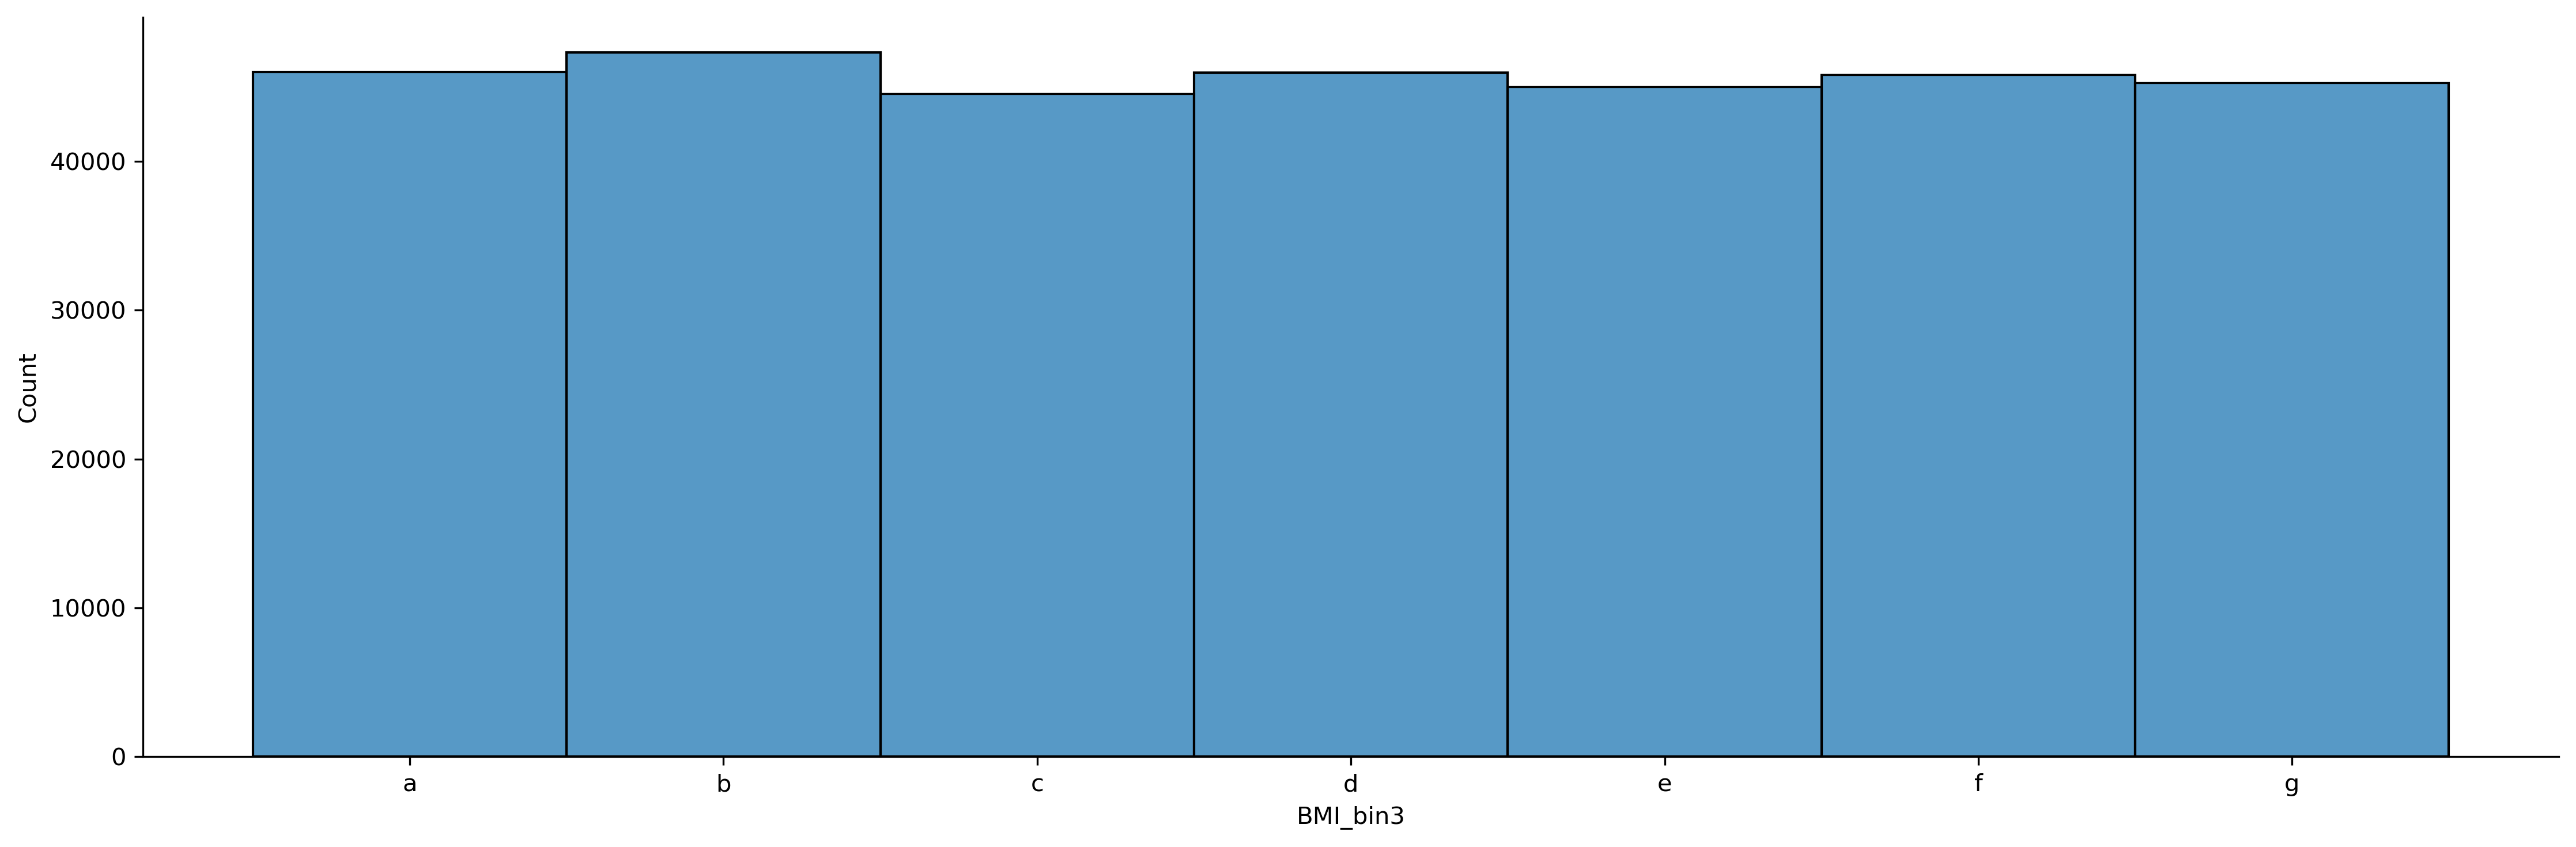

In [54]:
# BMI_bin3 분포 시각화

sns.displot(df1['BMI_bin3'],height = 5, aspect = 3)

---

다음 셀 코드 돌리기 위한 방법

In [6]:
!pip uninstall -y xverse

# 1. 최신 xverse 재설치
!pip install xverse --quiet

# 2. 내부 binning.py 수정 (algos.quantile → np.quantile)
!cp /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning_backup.py

# algos 대신 numpy import
!sed -i 's/from pandas.core import algorithms as algos/import numpy as np/g' /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py

# algos.quantile 호출 부분 정확히 교체
!sed -i 's/algos.quantile(X, np.linspace(0, 1, force_bins))/np.quantile(X.values.flatten(), np.linspace(0, 1, force_bins))/g' /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py

Found existing installation: xverse 1.0.5
Uninstalling xverse-1.0.5:
  Successfully uninstalled xverse-1.0.5
cp: /usr/local/lib/python3.11/dist-packages/xverse/transformer/_binning.py: No such file or directory
sed: 1: "/usr/local/lib/python3. ...": extra characters at the end of l command
sed: 1: "/usr/local/lib/python3. ...": extra characters at the end of l command


그리고 다시 실행

---

In [ ]:
# 가중치 증거 (Weight Of Evidence, WOE)와 정보 가치 (Information Value, IV)

# WOE (Weight Of Evidence):
# 신용평가나 로지스틱 회귀 모델에서, 
# 범주형 변수의 각 구간에 대해 사건(event)과 비사건(non-event)의 비율을 로그 변환하여 계산한 값
# 이는 각 구간의 예측력을 확인하는 데 사용되며, 구간별 리스크를 정량화하는 데 유용

# IV (Information Value):
# 전체 변수의 예측력을 나타내는 값으로, WOE를 활용하여 계산
# 일반적으로 IV 값이 클수록 해당 변수의 예측력이 높다고 판단

# WOE 및 IV를 이용하여 각 구간의 예측력 및 변수 중요도를 평가하는 방법

# -----------------------------------------------------------

# WOE를 사용한 변수 구간화
df2 = df.copy()  
# 원본 데이터프레임 df를 복사하여 df2에 저장함
# 원본을 보존하고, 이후 변형 작업에 사용할 사본을 생성함

# xverse 함수 적용을 위한 더미변수 변환
df2 = pd.get_dummies(df)
# 범주형 변수들을 0과 1로 구성된 더미변수(One-hot encoding) 형식으로 변환함
# xverse 패키지에서 사용하는 WOE 클래스는 수치형 입력만 허용하기 때문에 이 전처리가 필요함

# 구간화 할 컬럼(X), 기준 컬럼(y) 지정
X = df2[['PhysicalHealth']]  
# 독립 변수로 'PhysicalHealth' 컬럼만 선택하여 X에 저장함
# 이 변수에 대해 WOE 구간화를 수행할 예정임

y = df2[['KidneyDisease_Yes']]  
# 종속 변수(목표 변수)로 'KidneyDisease_Yes' 컬럼을 선택함
# 이진 분류 대상 컬럼이며, 질환 유무에 따라 WOE 값을 계산함

# WOE 분석을 위한 종속 변수 차원 축소
y = y.T.squeeze()  
# 종속 변수 y를 Series 형태로 변환함 (DataFrame → Series)
# xverse WOE 클래스는 종속 변수 입력을 Series 형태로 요구함

# WOE 분석 모델 객체 생성
clf = WOE()
# xverse 패키지의 WOE 클래스 객체 생성
# 이후 이 객체를 사용하여 WOE 구간화와 IV 계산을 수행함

# 입력 변수와 타깃 변수를 기반으로 WOE 학습 수행
clf.fit(X, y)
# WOE 객체에 fit() 함수를 적용하여 X(입력)와 y(타깃)을 기반으로 학습 수행
# 변수 값을 최적의 구간으로 분할하고, 각 구간에 대한 WOE 값을 계산함

# 각 구간의 경계값 및 WOE 값 정보 테이블 생성
a = clf.woe_df
# 학습 결과로 생성된 WOE 값, 구간 경계, 각 구간의 이벤트 비율 등을 포함한 데이터프레임을 a에 저장함

# 변수별 Information Value(IV) 정보 테이블 생성
b = clf.iv_df
# 각 변수의 예측력을 나타내는 정보가 포함된 IV(Information Value) 테이블을 b에 저장함

# WOE 테이블 출력
a.head()
# WOE 결과 테이블(a)의 상위 5개 행을 출력하여 구간화 결과와 WOE 값이 잘 생성되었는지 확인함


# -----------------------------------------------------------

# 변수 'PhysicalHealth'를 기준으로 WOE 변환을 수행한 결과 요약

# Variable_Name: 분석 대상 변수명을 의미함
# Category: 해당 변수의 값이 속한 구간을 의미함. 연속형 변수를 이산형 구간으로 나눈 형태
# Count: 각 구간에 속한 총 샘플 수를 의미함
# Event: 타깃 변수(y)가 1인 샘플 수를 의미함. 예측하고자 하는 '신장 질환 있음'의 수치
# Non_Event: 타깃 변수(y)가 0인 샘플 수를 의미함. '신장 질환 없음'의 수치
# Event_Rate: 해당 구간에서 Event가 발생한 비율을 의미함. Event / Count로 계산
# Non_Event_Rate: 해당 구간에서 Non_Event가 발생한 비율을 의미함. Non_Event / Count로 계산
# Event_Distribution: 전체 Event 중 해당 구간이 차지하는 비율을 의미함
# Non_Event_Distribution: 전체 Non_Event 중 해당 구간이 차지하는 비율을 의미함
# WOE (Weight of Evidence): 로그 오즈 비율을 의미하며, 해당 변수 구간이 타깃 변수와 얼마나 관련 있는지를 나타냄
#     - WOE > 0: 해당 구간은 이벤트 발생 가능성이 높은 방향을 가짐
#     - WOE < 0: 해당 구간은 이벤트 발생 가능성이 낮은 방향을 가짐
# Information_Value: 해당 변수 전체에 대한 예측력 정보를 나타냄
#     - IV 값이 클수록 해당 변수가 타깃 예측에 기여하는 정도가 큼
#     - 일반적으로 0.3 이상이면 예측력이 강한 변수로 판단함

# 예시 해석:
# 1번 구간 (-0.001, 1.0]은 건강한 집단이 많은 구간으로 Event 비율이 낮고 WOE가 음수인 특성을 가짐
# 2번 구간 (1.0, 30.0]은 건강 문제 가능성이 높은 집단으로 Event 비율이 높고 WOE가 양수인 특성을 가짐
# 전체적으로 해당 변수는 IV = 0.3087로 강한 예측력을 가지는 변수로 평가됨


,Variable_Name,Category,Count,Event,Non_Event,Event_Rate,Non_Event_Rate,Event_Distribution,Non_Event_Distribution,WOE,Information_Value
0,PhysicalHealth,"(-0.001, 1.0]",237078,5719.0,231359.0,0.024123,0.975877,0.485525,0.751127,-0.436343,0.308774
1,PhysicalHealth,"(1.0, 30.0]",82717,6060.0,76657.0,0.073262,0.926738,0.514475,0.248873,0.726202,0.308774


In [ ]:
# Information Value 확인

b.head()

# 변수별 Information Value를 요약한 테이블 생성 결과

# Variable_Name: 분석 대상 변수명을 의미함
# Information_Value: 해당 변수의 타깃 예측 기여도를 정량적으로 측정한 지표

# 해석 기준:
# IV < 0.02      : 예측력 거의 없음
# 0.02 ≤ IV < 0.1: 약한 예측력 보유
# 0.1 ≤ IV < 0.3 : 중간 수준 예측력 보유
# IV ≥ 0.3       : 강한 예측력 보유

# 예시:
# 변수 'PhysicalHealth'의 IV는 0.308774로, 타깃 변수(KidneyDisease)에 대해 강한 예측력을 지님
# 해당 변수는 WOE 기반 이산화 및 스코어링 모델 구축 시 주요 설명 변수로 활용 가능함


,Variable_Name,Information_Value
0,PhysicalHealth,0.308774
